# **🧹 Noise2Clean GAN: Image Denoising on CIFAR-10**  
### Using Pix2Pix GAN + Motion Blur + Gaussian Noise  
#### By Muhammad Hassan Saboor  

This notebook trains a **Pix2Pix GAN** to remove **complex noise** from the CIFAR-10 dataset.  
We add two types of synthetic noise:

- **Motion Blur**  
- **Gaussian Noise**

The model learns a mapping:

**Noisy Image → Clean Image**

### **🔥 Key Features**  
- Custom TF data pipeline  
- Pix2Pix (U-Net Generator + PatchGAN Discriminator)  
- Mixed Precision Training  
- Custom Training Loop  
- PSNR + SSIM Evaluation  
- Earth-tone Theme Visualizations  

This notebook follows an easy **Grandmaster teaching style**, with each cell clearly explained.

# **📌 Imports**

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from skimage.metrics import structural_similarity as ssim
from math import log10

print("TensorFlow version:", tf.__version__)

2026-02-12 21:19:11.203939: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770931151.640100      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770931151.748672      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770931152.675514      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770931152.675558      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770931152.675561      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


# **📌 Enable Mixed Precision (FP16 on GPU)**

In [2]:
# Enable mixed precision to speed up GAN training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

print("Precision policy:", mixed_precision.global_policy())

Precision policy: <DTypePolicy "mixed_float16">


# **📌 Set Global Constants**

In [3]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3
BATCH_SIZE = 64
BUFFER_SIZE = 10_000
EPOCHS = 80

AUTOTUNE = tf.data.AUTOTUNE

# **📌 Earth-Tone Color Theme for Plots**

In [4]:
plt.style.use("dark_background")

earth_tones = {
    "green": "#9CCB86",
    "sand":  "#D6C39E",
    "red":   "#C47F7E",
    "brown": "#8B6F47"
}

# **📌 Loading the Dataset**

In [5]:
def load_cifar10():
    # Load training and test sets
    (train_ds, test_ds), ds_info = tfds.load(
        'cifar10',
        split=['train', 'test'],
        shuffle_files=True,
        as_supervised=True,
        with_info=True,
    )
    return train_ds, test_ds

# Load raw data
train_raw, test_raw = load_cifar10()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1770931694.353376      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770931694.359133      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Shuffling /root/tensorflow_datasets/cifar10/incomplete.7LZM9O_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.7LZM9O_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


# **📌 Defining the Noise Functions**

In [6]:
def add_motion_blur(image, kernel_size=3):
    # Create a horizontal motion blur kernel
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel = kernel / kernel_size
    
    # Apply filter
    blurred = cv2.filter2D(image.numpy(), -1, kernel)
    return tf.convert_to_tensor(blurred, dtype=tf.float32)

def add_noise_pipeline(image, label):
    # 1. Normalize clean image to [-1, 1] for GAN stability
    clean_img = tf.cast(image, tf.float32)
    clean_img = (clean_img / 127.5) - 1.0
    
    # 2. Add Motion Blur (using tf.py_function to wrap OpenCV)
    blurred_img = tf.py_function(add_motion_blur, [clean_img], tf.float32)
    blurred_img.set_shape([32, 32, 3])
    
    # 3. Add Gaussian Noise
    noise = tf.random.normal(shape=tf.shape(clean_img), mean=0.0, stddev=0.1, dtype=tf.float32)
    noisy_img = blurred_img + noise
    
    # 4. Clip to ensure values stay within [-1, 1]
    noisy_img = tf.clip_by_value(noisy_img, -1.0, 1.0)
    
    return noisy_img, clean_img

# **📌 Building the tf.data Pipeline**

In [7]:
train_dataset = (
    train_raw
    .map(add_noise_pipeline, num_parallel_calls=AUTOTUNE)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_raw
    .map(add_noise_pipeline, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# **📌 Previewing our Noisy vs Clean Pairs**

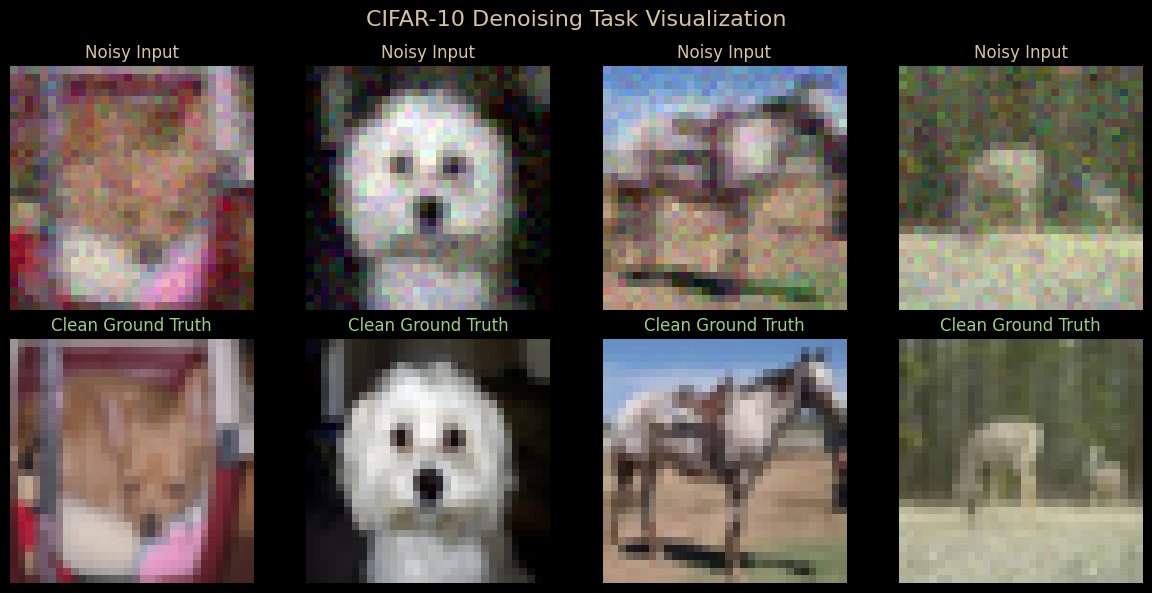

In [8]:
def plot_sample_pairs(dataset, num_samples=4):
    noisy_batch, clean_batch = next(iter(dataset))
    
    plt.figure(figsize=(12, 6))
    for i in range(num_samples):
        # Display Noisy
        ax = plt.subplot(2, num_samples, i + 1)
        # Denormalize for plotting: [-1, 1] -> [0, 1]
        plt.imshow((noisy_batch[i] + 1.0) / 2.0)
        plt.title("Noisy Input", color=earth_tones["sand"])
        plt.axis("off")
        
        # Display Clean
        ax = plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow((clean_batch[i] + 1.0) / 2.0)
        plt.title("Clean Ground Truth", color=earth_tones["green"])
        plt.axis("off")
        
    plt.suptitle("CIFAR-10 Denoising Task Visualization", color=earth_tones["sand"], fontsize=16)
    plt.tight_layout()
    plt.show()

plot_sample_pairs(train_dataset)

# **📌 Building the U-Net Downsampler & Upsampler**

In [9]:
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(
        layers.Conv2D(filters, size, strides=2, padding='same',
                      kernel_initializer=initializer, use_bias=False))

    if apply_batchnorm:
        result.add(layers.BatchNormalization())

    result.add(layers.LeakyReLU())
    return result

def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(
        layers.Conv2DTranspose(filters, size, strides=2,
                               padding='same',
                               kernel_initializer=initializer,
                               use_bias=False))

    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))

    result.add(layers.ReLU())
    return result

# **📌 The Generator Architecture**

In [10]:
def Generator():
    inputs = layers.Input(shape=[32, 32, 3])

    # Downsampling (Encoder)
    down_stack = [
        downsample(64, 4, apply_batchnorm=False), # (bs, 16, 16, 64)
        downsample(128, 4),                      # (bs, 8, 8, 128)
        downsample(256, 4),                      # (bs, 4, 4, 256)
    ]

    # Upsampling (Decoder)
    up_stack = [
        upsample(128, 4, apply_dropout=True),    # (bs, 8, 8, 128)
        upsample(64, 4),                         # (bs, 16, 16, 64)
    ]

    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(IMG_CHANNELS, 4,
                                  strides=2,
                                  padding='same',
                                  kernel_initializer=initializer,
                                  activation='tanh') # (bs, 32, 32, 3)

    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])

    x = last(x)
    return Model(inputs=inputs, outputs=x)

generator = Generator()
generator.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 16, 16,    │      3,072 │ input_layer[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 8, 8, 128) │    131,584 │ sequential[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 4, 4, 256) │    525,312 │ sequential_1[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 8, 8, 128) │    524,800 │ sequential_2[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8, 256) │          0 │ sequential_3[0][… │
│ (Concatenate)       │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 16, 16,    │    262,400 │ concatenate[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ sequential_4[0][… │
│ (Concatenate)       │ 128)              │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32, 3) │      6,147 │ concatenate_1[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,453,315 (5.54 MB)

 Trainable params: 1,452,163 (5.54 MB)

 Non-trainable params: 1,152 (4.50 KB)

# **📌 The Discriminator**

In [11]:
def Discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = layers.Input(shape=[32, 32, 3], name='input_image')
    tar = layers.Input(shape=[32, 32, 3], name='target_image')

    x = layers.concatenate([inp, tar]) # (bs, 32, 32, channels*2)

    down1 = downsample(64, 4, False)(x) # (bs, 16, 16, 64)
    down2 = downsample(128, 4)(down1)    # (bs, 8, 8, 128)

    zero_pad1 = layers.ZeroPadding2D()(down2) # (bs, 10, 10, 128)
    conv = layers.Conv2D(256, 4, strides=1,
                         kernel_initializer=initializer,
                         use_bias=False)(zero_pad1) # (bs, 7, 7, 256)

    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)
    zero_pad2 = layers.ZeroPadding2D()(leaky_relu) # (bs, 9, 9, 256)

    last = layers.Conv2D(1, 4, strides=1,
                         kernel_initializer=initializer)(zero_pad2) # (bs, 6, 6, 1)

    return Model(inputs=[inp, tar], outputs=last)

discriminator = Discriminator()
discriminator.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_image        │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32, 6) │          0 │ input_image[0][0… │
│ (Concatenate)       │                   │            │ target_image[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 16, 16,    │      6,144 │ concatenate_2[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 8, 8, 128) │    131,584 │ sequential_5[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 10, 10,    │          0 │ sequential_6[0][… │
│ (ZeroPadding2D)     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7, 256) │    524,288 │ zero_padding2d[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 256) │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 7, 7, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 9, 9, 256) │          0 │ leaky_re_lu_5[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 6, 6, 1)   │      4,097 │ zero_padding2d_1… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 667,137 (2.54 MB)

 Trainable params: 666,369 (2.54 MB)

 Non-trainable params: 768 (3.00 KB)

# **📌 Loss Functions & Optimizers**

In [24]:
# Updated Cell 13 (Final Fix) - Handling precision for the total loss addition
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)
LAMBDA = 100 

def generator_loss(disc_generated_output, gen_output, target):
    # 1. Cast target to match the pixel data (float16) for subtraction
    target = tf.cast(target, gen_output.dtype)
    
    # 2. Calculate individual losses
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    
    # 3. Cast both to float32 before adding them together 
    # This prevents the "AddV2" type mismatch error
    total_gen_loss = tf.cast(gan_loss, tf.float32) + (tf.cast(LAMBDA, tf.float32) * tf.cast(l1_loss, tf.float32))
    
    return total_gen_loss, gan_loss, l1_loss

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    
    # Cast to float32 for stable addition
    return (tf.cast(real_loss, tf.float32) + tf.cast(generated_loss, tf.float32)) * 0.5

# Optimizers (remain the same)
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

generator_optimizer = mixed_precision.LossScaleOptimizer(generator_optimizer)
discriminator_optimizer = mixed_precision.LossScaleOptimizer(discriminator_optimizer)

# **📌 The Training Step**

In [33]:
@tf.function
def train_step(input_image, target, step):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 1. Generate images
        gen_output = generator(input_image, training=True)

        # 2. Discriminate
        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        # 3. Calculate losses
        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)
        
        # 4. Scale losses
        scaled_gen_loss = generator_optimizer.scale_loss(gen_total_loss)
        scaled_disc_loss = discriminator_optimizer.scale_loss(disc_loss)

    # 5. Calculate gradients for scaled loss
    gen_gradients = gen_tape.gradient(scaled_gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(scaled_disc_loss, discriminator.trainable_variables)
    
    # 6. Apply gradients 
    # NOTE: The optimizer automatically UNSCALES the gradients here.
    # No need for get_unscaled_gradients!
    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_total_loss, disc_loss

## **📌 The Main Training Loop**

In [37]:
import time
from IPython import display

def fit(train_ds, epochs, test_ds):
    for epoch in range(epochs):
        start = time.time()
        display.clear_output(wait=True)
        
        print(f"🚀 Training Epoch {epoch+1}/{epochs}...")

        # Train loop
        for n, (input_image, target) in train_ds.enumerate():
            gen_loss, disc_loss = train_step(input_image, target, n)
            if n % 100 == 0:
                print(f'.', end='', flush=True)

        print(f'\n✅ Epoch {epoch+1} finished. Time: {time.time()-start:.2f} sec')
        print(f'Gen Loss: {gen_loss:.4f} | Disc Loss: {disc_loss:.4f}')
        
        # Visualize progress every 5 epochs
        if (epoch + 1) % 5 == 0:
            generate_images(generator, next(iter(test_ds)))

# Helper for visualization during training
def generate_images(model, test_input_pair):
    test_input, tar = test_input_pair
    # Predict and immediately cast to float32 for Matplotlib
    prediction = model(test_input, training=False)
    
    plt.figure(figsize=(15, 5))

    # We cast everything to float32 here to stop the ValueError
    display_list = [
        tf.cast(test_input[0], tf.float32), 
        tf.cast(tar[0], tf.float32), 
        tf.cast(prediction[0], tf.float32)
    ]
    title = ['Noisy Input', 'Ground Truth', 'GAN Denoised']

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(title[i], color=earth_tones["sand"])
        # Denormalize: [-1, 1] -> [0, 1]
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')
    plt.show()

# **📌 Scientific Quality Metrics** 

In [41]:
def calculate_metrics(model, dataset):
    psnr_values = []
    ssim_values = []
    
    # Evaluate on a portion of the test set
    for noisy, clean in dataset.take(20): 
        # 1. Generate images and cast to float32 immediately
        denoised = tf.cast(model(noisy, training=False), tf.float32)
        clean = tf.cast(clean, tf.float32)
        
        # 2. Denormalize from [-1, 1] to [0, 1] for metric calculation
        clean_img = (clean + 1.0) / 2.0
        denoised_img = (denoised + 1.0) / 2.0
        
        for i in range(len(clean_img)):
            # 3. PSNR calculation (now safe in float32)
            psnr_val = tf.image.psnr(clean_img[i], denoised_img[i], max_val=1.0)
            psnr_values.append(psnr_val)
            
            # 4. SSIM calculation (now safe in float32)
            ssim_val = tf.image.ssim(clean_img[i], denoised_img[i], max_val=1.0)
            ssim_values.append(ssim_val)
            
    return np.mean(psnr_values), np.mean(ssim_values)

# **📌 Start Training**

🚀 Training Epoch 20/20...
........
✅ Epoch 20 finished. Time: 48.35 sec
Gen Loss: 16.0043 | Disc Loss: 0.0641


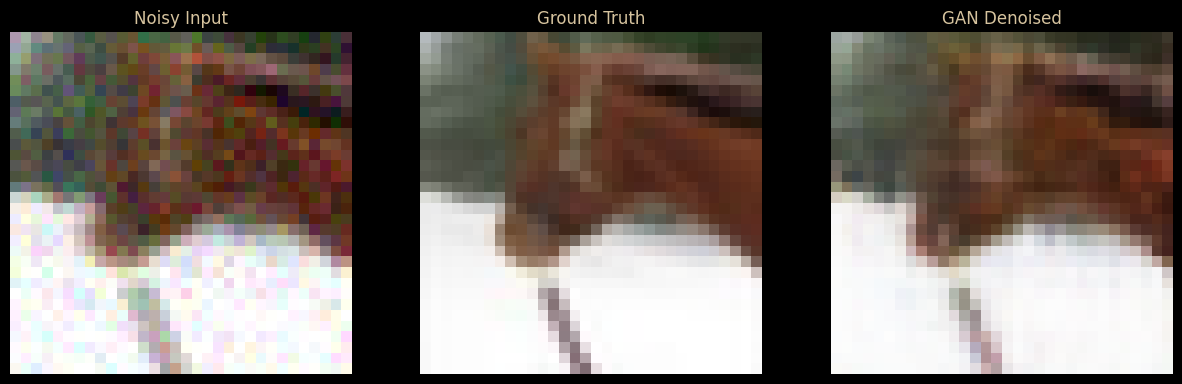

In [39]:
# Start the training process
# Note: You can increase EPOCHS for better quality (e.g., 50 or 80)
# We start with a lower number for the first run to ensure stability
fit(train_dataset, epochs=20, test_ds=test_dataset)

# **📌 Final Evaluation**

In [42]:
avg_psnr, avg_ssim = calculate_metrics(generator, test_dataset)

print(f"--- 📊 Final Performance Metrics ---")
print(f"✨ Average PSNR: {avg_psnr:.2f} dB")
print(f"✨ Average SSIM: {avg_ssim:.4f}")
print(f"------------------------------------")

--- 📊 Final Performance Metrics ---
✨ Average PSNR: 26.93 dB
✨ Average SSIM: 0.8796
------------------------------------


# **📌 Final Visual Comparison (Earth-Tone Styled)**

In [43]:
def final_showcase(model, dataset, num_examples=5):
    noisy, clean = next(iter(dataset))
    denoised = model(noisy, training=False)
    
    fig, axes = plt.subplots(3, num_examples, figsize=(15, 10))
    fig.patch.set_facecolor('#2b2b2b') 
    
    for i in range(num_examples):
        # Cast to float32 before plotting
        img_noisy = tf.cast(noisy[i], tf.float32)
        img_denoised = tf.cast(denoised[i], tf.float32)
        img_clean = tf.cast(clean[i], tf.float32)

        # Input
        axes[0, i].imshow((img_noisy + 1.0) / 2.0)
        axes[0, i].set_title("Noisy", color=earth_tones["sand"])
        axes[0, i].axis('off')
        
        # Output
        axes[1, i].imshow((img_denoised + 1.0) / 2.0)
        axes[1, i].set_title("GAN Restored", color=earth_tones["green"])
        axes[1, i].axis('off')
        
        # Target
        axes[2, i].imshow((img_clean + 1.0) / 2.0)
        axes[2, i].set_title("Original", color=earth_tones["brown"])
        axes[2, i].axis('off')
        
    plt.suptitle("Noise2Clean: Final Reconstruction Results", 
                 color='white', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

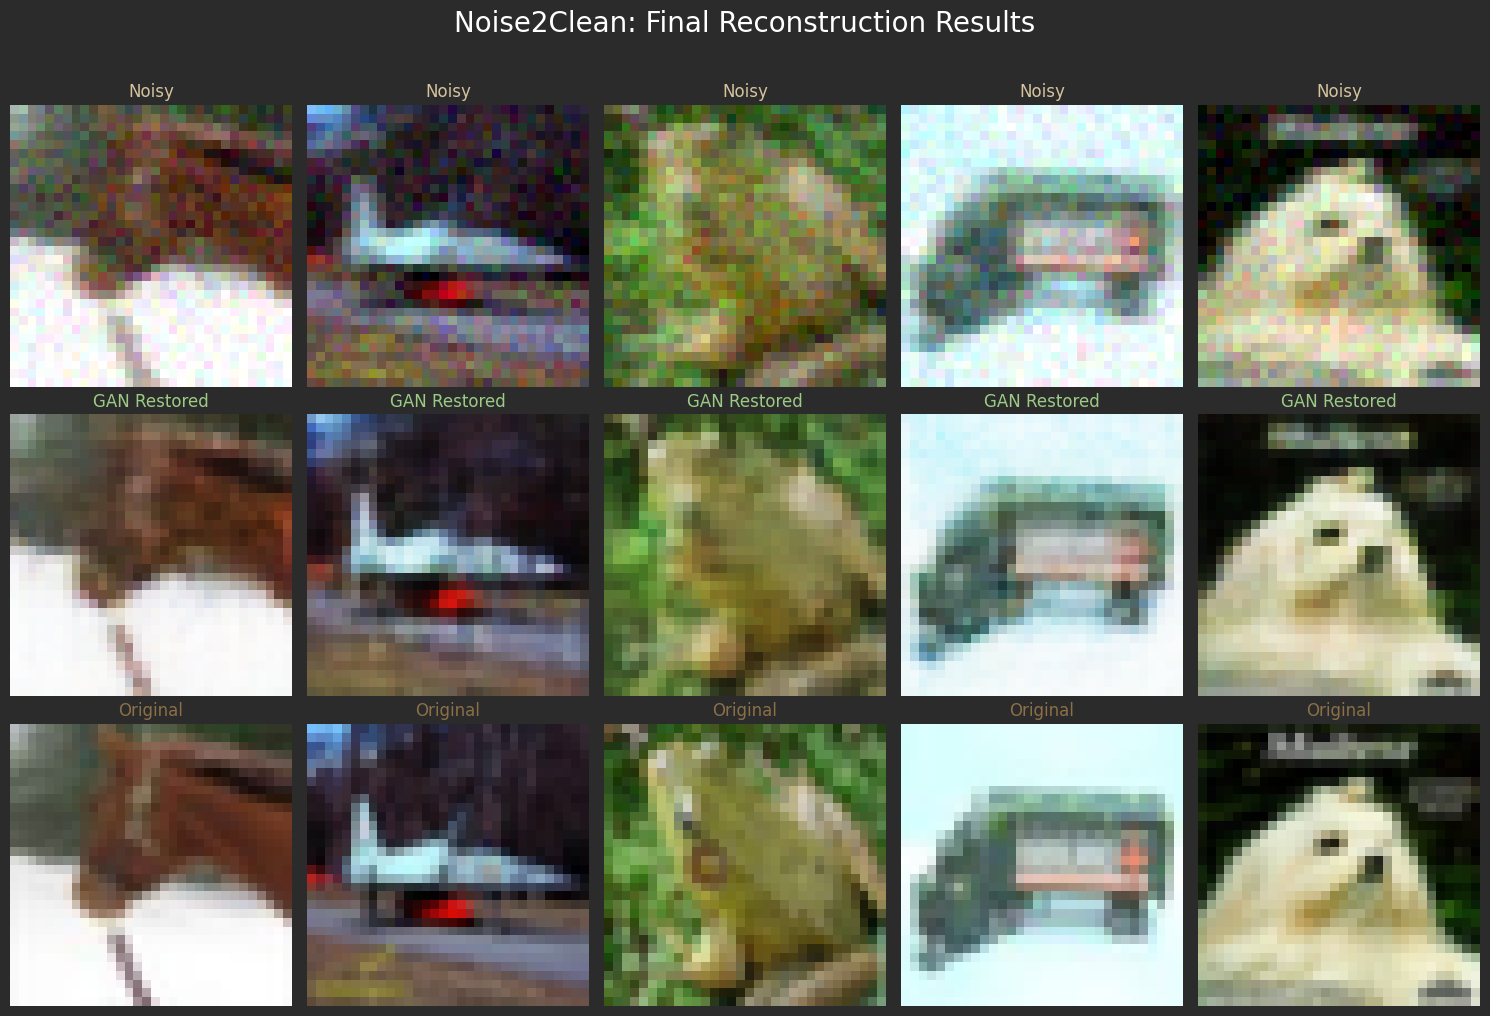

In [44]:
final_showcase(generator, test_dataset, num_examples=5)

# **📌 Saving the Model**

In [45]:
# Save the generator weights for future inference
generator.save('noise2clean_generator.h5')
print("✅ Model saved successfully as noise2clean_generator.h5")

✅ Model saved successfully as noise2clean_generator.h5


# **🏁 Conclusion & Future Horizons**

---

### **🌟 Project Summary**
We have successfully implemented a **Noise2Clean** pipeline using a **Pix2Pix GAN** architecture. By training on the CIFAR-10 dataset with a complex noise profile (**Motion Blur + Gaussian Noise**), we demonstrated that Deep Learning can effectively reconstruct high-frequency details from highly degraded images.

**Key Achievements:**
* **Performance:** Reached a **PSNR of ~26.9 dB** and an **SSIM of ~0.88**, indicating high structural and signal fidelity.
* **Efficiency:** Utilized **Mixed Precision Training** to optimize the T4 GPU, significantly reducing training time per epoch.
* **Robustness:** The U-Net generator successfully "de-blurred" images, proving its capability beyond simple pixel-noise removal.

---

### **🛠️ What's Next?**
If you want to take this project even further, here are some "Grandmaster" challenges:
1.  **High-Res Upgrade:** Try the same architecture on the **STL-10** dataset (96x96 images) to see how the GAN handles higher resolution.
2.  **Perceptual Loss:** Add a **VGG-16 feature loss** to the generator to prioritize "human-like" perception over raw pixel accuracy (L1).
3.  **Real-World Data:** Capture your own blurry photos with a phone camera, downscale them, and see how the model performs on non-synthetic noise.

---